# Data Visualization – Lab 02
## Exploration and Visualization of World Development Indicators (WDI) Data
**Instructor:** Võ Nhật Tân  
**Group:** [MSSV_1, MSSV_2, MSSV_3]  
**Date:** 25/03/2026
---


In [18]:
# Install libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


In [19]:
# Dataset path
import os
DATA_PATH = '/home/nesfan/Desktop/HCMUS/Nam3/HK2/TQH/DataVis-Lab2/Notebook/data/dataset.csv'

# List of target countries and indicators (easy to extend)
COUNTRY_WHITELIST = [
    'VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'JPN', 'KOR',
    'DEU', 'FRA', 'GBR', 'SWE', 'USA', 'CAN', 'BRA', 'MEX', 'ZAF', 'NGA'
]

SERIES_WHITELIST = [
    'SE.TER.ENRR',
    'SL.UEM.TOTL.ZS',
    'SL.SRV.EMPL.ZS',
    'SG.GEN.PARL.ZS',
    'SE.XPD.TOTL.GD.ZS',
    'SH.XPD.GHED.GE.ZS',
    'NY.GDP.PCAP.CD'
]

The dataset for this analysis focuses on the indicator:
- **School enrollment, tertiary (% gross)** – `SE.TER.ENRR`

The data includes 20 countries (VNM, THA, IDN, PHL, IND, BGD, PAK, CHN, JPN, KOR, DEU, FRA, GBR, SWE, USA, CAN, BRA, MEX, ZAF, NGA) for the period 2000–2024.

In [20]:
# Read data (prefer utf-8-sig, fallback latin-1)
try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

print(f"Initial size: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

Initial size: 1824 rows × 29 columns

Column names:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


### 1.2 Data Structure

**Rows:** Each row corresponds to a country for the `SE.TER.ENRR` indicator over the years.  
**Columns:**
| Field | Description |
|---|---|
| `Country Name` | Country name |
| `Country Code` | Country code (ISO 3-letter) |
| `Series Name` | Indicator name |
| `Series Code` | Indicator code |
| `2000 [YR2000] … 2024 [YR2024]` | Indicator value per year |

In addition to the main data rows, there are footer/metadata rows at the end of the file which will be removed during the cleaning step.

In [21]:
# View raw data
df_raw.head(10)


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,174.930991,138.706822,178.954088,198.871116,221.763654,254.184249,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
1,Afghanistan,AFG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,NaN,NaN,NaN,1.374350,1.390640,NaN,...,NaN,NaN,NaN,9.995920,NaN,10.854360,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,NaN,NaN,NaN,0.571370,0.578160,NaN,...,NaN,NaN,NaN,5.020660,NaN,5.936540,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.255800,4.543970,4.343190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Proportion of seats held by women in national ...,SG.GEN.PARL.ZS,NaN,NaN,NaN,NaN,NaN,27.309237,...,27.710843,27.710843,27.710843,NaN,27.868852,27.016129,27.016129,NaN,NaN,NaN
5,Afghanistan,AFG,Domestic general government health expenditure...,SH.XPD.GHED.GD.ZS,NaN,NaN,0.084181,0.650963,0.542926,0.529184,...,0.522673,0.600130,0.643134,0.552396,0.497056,1.186212,0.710364,0.181471,0.247749,NaN
6,Afghanistan,AFG,Domestic general government health expenditure...,SH.XPD.GHED.GE.ZS,NaN,NaN,1.212456,5.457679,3.602968,3.381221,...,2.014406,2.141105,2.319116,1.909047,1.775260,4.246028,3.961011,1.126057,1.460184,NaN
7,Afghanistan,AFG,Female share of employment in senior and middl...,SL.EMP.SMGT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.255000,NaN,NaN,5.889000,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Employment in services (% of total employment)...,SL.SRV.EMPL.ZS,23.672991,22.838424,24.453125,24.781849,24.833148,25.707719,...,33.732115,35.239837,36.802134,37.016679,37.513539,35.535277,30.151586,29.427214,29.498492,29.502168
9,Afghanistan,AFG,"Labor force with advanced education, female (%...",SL.TLF.ADVN.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,48.643000,NaN,NaN,34.145000,32.509000,NaN,NaN,NaN


In [22]:
# Data types for each column
print("Data types of each column:")
print(df_raw.dtypes)


Data types of each column:
Country Name         str
Country Code         str
Series Name          str
Series Code          str
2000 [YR2000]    float64
2001 [YR2001]    float64
2002 [YR2002]    float64
2003 [YR2003]    float64
2004 [YR2004]    float64
2005 [YR2005]    float64
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
dtype: object


In [23]:
# Clean by schema: only keep 20 countries and 7 target indicators
# Independent of manual footer filtering
schema_ok = (
    df_raw['Country Name'].notna() &
    df_raw['Country Code'].notna() &
    df_raw['Series Name'].notna() &
    df_raw['Series Code'].notna()
)

df = df_raw[
    schema_ok &
    df_raw['Country Code'].isin(COUNTRY_WHITELIST) &
    df_raw['Series Code'].isin(SERIES_WHITELIST)
].copy().reset_index(drop=True)

print(f"Number of rows after schema filtering: {len(df)}")
print(f"Number of unique countries: {df['Country Code'].nunique()}")
print(f"Number of unique indicators: {df['Series Code'].nunique()}")

missing_countries = sorted(set(COUNTRY_WHITELIST) - set(df['Country Code'].unique()))
missing_series = sorted(set(SERIES_WHITELIST) - set(df['Series Code'].unique()))
print(f"Missing Country Codes: {missing_countries}")
print(f"Missing Series Codes: {missing_series}")

Number of rows after schema filtering: 140
Number of unique countries: 20
Number of unique indicators: 7
Missing Country Codes: []
Missing Series Codes: []


### 1.3 Descriptive Statistical Analysis

Descriptive statistics for numerical values (years 2000–2024) include: count, mean, std, min, max, and percentiles (25%, 50%, 75%).

In [24]:
# Get list of year columns in WDI format and limit to 2000-2024
year_cols = [
    c for c in df.columns
    if c.startswith('20') and c.endswith(']') and int(c[:4]) >= 2000 and int(c[:4]) <= 2024
]
year_cols = sorted(year_cols, key=lambda x: int(x[:4]))

print(f"Number of years with data: {len(year_cols)} (from {year_cols[0]} to {year_cols[-1]})")

# Convert to numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nDescriptive Statistics:\n{df_years.describe().round(3)}")

Number of years with data: 25 (from 2000 [YR2000] to 2024 [YR2024])

Descriptive Statistics:
       2000 [YR2000]  2001 [YR2001]  2002 [YR2002]  2003 [YR2003]  \
count        120.000        121.000        124.000        124.000   
mean        2004.360       1917.261       1951.346       2224.582   
std         7081.191       6779.032       6955.771       7922.439   
min            0.614          0.611          0.615          0.612   
25%            5.535          5.861          5.902          5.957   
50%           14.153         15.945         16.031         16.361   
75%           62.678         62.639         62.188         62.586   
max        39169.360      37133.623      37997.760      39490.275   

       2004 [YR2004]  2005 [YR2005]  2006 [YR2006]  2007 [YR2007]  \
count        125.000        127.000        124.000        124.000   
mean        2476.150       2572.056       2797.759       3093.447   
std         8835.490       9136.606       9738.789      10748.464   
min      

In [25]:
# Detailed statistics for each indicator
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} years with data")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


   Series Code : NY.GDP.PCAP.CD
   Count  : 25 / 25 years with data
   Mean   : 1229.9129
   Std    : 829.1672
   Min    : 393.8864
   Max    : 2716.4859
   25%    : 490.3880
   50%    : 859.6805
   75%    : 1965.2437
   Series Code : SE.TER.ENRR
   Count  : 24 / 25 years with data
   Mean   : 13.9342
   Std    : 7.0246
   Min    : 5.2517
   Max    : 24.2003
   25%    : 6.8459
   50%    : 13.4556
   75%    : 20.3514
   Series Code : SE.XPD.TOTL.GD.ZS
   Count  : 23 / 25 years with data
   Mean   : 2.0048
   Std    : 0.2671
   Min    : 1.1309
   Max    : 2.2022
   25%    : 1.9917
   50%    : 2.0948
   75%    : 2.1362
   Series Code : SG.GEN.PARL.ZS
   Count  : 22 / 25 years with data
   Mean   : 16.0019
   Std    : 6.8511
   Min    : 2.0000
   Max    : 20.9169
   25%    : 14.8551
   50%    : 19.7143
   75%    : 20.2857
   Series Code : SH.XPD.GHED.GE.ZS
   Count  : 24 / 25 years with data
   Mean   : 3.9049
   Std    : 0.7993
   Min    : 2.4716
   Max    : 5.2115
   25%    : 3.5281
   5

### 1.4 Percentage of Missing Values – Before Imputation


In [26]:
# ── % Missing Values – BEFORE IMPUTATION ──
total_cells = df_years.size           # rows × years
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nOverview:")
print(f"   Total data cells : {total_cells}")
print(f"   Missing cells    : {total_missing}")
print(f"   Missing rate     : {overall_pct}%")

# By INDICATOR (row)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# By YEAR (column)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nBy INDICATOR (row):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Missing: {n}/{len(year_cols)} years ({p}%)")

print(f"\nBy YEAR (column):")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Missing: {n}/{len(df_years)} indicators ({p}%) {bar}")



Overview:
   Total data cells : 3500
   Missing cells    : 289
   Missing rate     : 8.26%

By INDICATOR (row):
   GDP per capita (current US$) ... | Missing: 0/25 years (0.0%)
   School enrollment, tertiary (% gross) ... | Missing: 1/25 years (4.0%)
   Government expenditure on education, total (% of GDP) ... | Missing: 2/25 years (8.0%)
   Proportion of seats held by women in national parliaments (% ... | Missing: 3/25 years (12.0%)
   Domestic general government health expenditure (% of general ... | Missing: 1/25 years (4.0%)
   Employment in services (% of total employment) (modeled ILO  ... | Missing: 0/25 years (0.0%)
   Unemployment, total (% of total labor force) (modeled ILO es ... | Missing: 0/25 years (0.0%)
   GDP per capita (current US$) ... | Missing: 0/25 years (0.0%)
   School enrollment, tertiary (% gross) ... | Missing: 14/25 years (56.0%)
   Government expenditure on education, total (% of GDP) ... | Missing: 3/25 years (12.0%)
   Proportion of seats held by women 

### 1.5 Data Preprocessing

#### 1.5.1 Handling Missing Values (Imputation)

Since this is time-series data, we use **Linear Interpolation** for imputation, which is appropriate for the long-term trends of development indicators.


In [27]:
# --- Step 1: Parse all year columns to float first ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Convert '..' and garbage strings -> NaN, cast to float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Data types of year columns after parsing:")
print(df_clean[year_cols].dtypes.value_counts())

# --- Step 2: Linear Interpolation for each indicator ---
for i in range(len(df_clean)):
    vals = df_clean.loc[i, year_cols].astype(float)
    interp = vals.interpolate(method='linear', limit_direction='both')
    interp = interp.ffill().bfill()   # remaining missing values at start/end
    df_clean.loc[i, year_cols] = interp.values

# Verify
df_check = df_clean[year_cols].apply(pd.to_numeric, errors='coerce')
print(f"\nKiem tra sau imputation: {df_check.isnull().sum().sum()} o con thieu")


Data types of year columns after parsing:
float64    25
Name: count, dtype: int64

Kiem tra sau imputation: 0 o con thieu


In [28]:
# Dataset after preprocessing
print("Dataset after preprocessing:\n")
df_clean[['Country Name', 'Country Code', 'Series Name', 'Series Code']].head(3)


Dataset after preprocessing:



,Country Name,Country Code,Series Name,Series Code
0,Bangladesh,BGD,GDP per capita (current US$),NY.GDP.PCAP.CD
1,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR
2,Bangladesh,BGD,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS


## Question 1: Monitoring the growth rate of tertiary education enrollment in different countries


In [29]:
# Filter tertiary enrollment indicator and melt data to long format
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

print(f"Number of countries in analysis: {ter_long['Country Code'].nunique()}")
print(f"Number of long format data rows: {len(ter_long)}")
ter_long.head()

Number of countries in analysis: 20
Number of long format data rows: 500


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
0,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],5.251660,2000
1,Brazil,BRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],43.230862,2000
2,Canada,CAN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],58.519119,2000
3,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],7.577780,2000
4,France,FRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],50.603081,2000


In [30]:
# Manual Region mapping and representative countries (1 per region)
region_map = {
    'VNM': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'PHL': 'East Asia & Pacific',
    'IND': 'South Asia',
    'BGD': 'South Asia',
    'PAK': 'South Asia',
    'CHN': 'East Asia & Pacific',
    'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific',
    'DEU': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia',
    'GBR': 'Europe & Central Asia',
    'SWE': 'Europe & Central Asia',
    'USA': 'North America',
    'CAN': 'North America',
    'BRA': 'Latin America & Caribbean',
    'MEX': 'Latin America & Caribbean',
    'ZAF': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
}
region_df = pd.DataFrame(list(region_map.items()), columns=['Country Code', 'Region'])

# 1 representative country per region
REPRESENTATIVE = {
    'North America':     'USA',
    'Europe & Central Asia': 'DEU',
    'East Asia & Pacific': 'JPN',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Middle East, North Africa, Afghanistan & Pakistan': 'PAK',
    'Sub-Saharan Africa': 'ZAF',
}

# Developing representative countries (1 per developing region)
DEV_REPRESENTATIVE = {
    'East Asia & Pacific': 'VNM',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Sub-Saharan Africa': 'ZAF',
}

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

print(f"Number of unique regions: {ter_long['Region'].nunique()}")
print(f"Number of rows missing Region: {missing_region}")
print(f"Country Codes failed to map Region: {missing_codes}")

ter_long.head()


Number of unique regions: 6
Number of rows missing Region: 0
Country Codes failed to map Region: []


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Bangladesh,BGD,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],5.251660,2000,South Asia
1,Brazil,BRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],43.230862,2000,Latin America & Caribbean
2,Canada,CAN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],58.519119,2000,North America
3,China,CHN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],7.577780,2000,East Asia & Pacific
4,France,FRA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],50.603081,2000,Europe & Central Asia


### Chart Selection and Rationale

**Chart 1 - Line Chart:**
- **Data properties:** Time-series of tertiary enrollment rates across countries.
- **Rationale:** Line chart allows easy tracking of trends over time for each country, comparing slopes (growth rates) and relative levels across the 20 countries.

**Chart 2 - Bar Chart:**
- **Data properties:** Period growth rate (single value per country).
- **Rationale:** Bar chart allows direct side-by-side comparison of which countries grew fastest/slowest over the full period.


In [31]:
# Filter to representative countries (1 per region)
rep_codes = list(REPRESENTATIVE.values())
rep_df = region_df[region_df['Country Code'].isin(rep_codes)].copy()

# Merge region info to ter_long
ter_rep = ter_long[ter_long['Country Code'].isin(rep_codes)].copy()

# Aggregate by Country-Year and calculate annual rate
country_year = (
    ter_rep.dropna(subset=['Value'])
    .groupby(['Country Name', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Country Name', 'Year'])
)

country_year['delta_abs'] = country_year.groupby('Country Name')['Value'].diff()
country_year['pct_change'] = country_year.groupby('Country Name')['Value'].pct_change() * 100

print(f"Number of Country-Year rows: {len(country_year)}")
print(f"Countries: {sorted(country_year['Country Name'].unique())}")
country_year.head(12)


Number of Country-Year rows: 175
Countries: ['Brazil', 'Germany', 'India', 'Japan', 'Pakistan', 'South Africa', 'United States']


,Country Name,Year,Value,delta_abs,pct_change
0,Brazil,2000,43.230862,NaN,NaN
1,Brazil,2001,43.230862,0.0,0.0
2,Brazil,2002,43.230862,0.0,0.0
3,Brazil,2003,43.230862,0.0,0.0
4,Brazil,2004,43.230862,0.0,0.0
5,Brazil,2005,43.230862,0.0,0.0
6,Brazil,2006,43.230862,0.0,0.0
7,Brazil,2007,43.230862,0.0,0.0
8,Brazil,2008,43.230862,0.0,0.0
9,Brazil,2009,43.230862,0.0,0.0


Number of Country-Year rows: 70
Countries: ['Brazil', 'Germany', 'India', 'Japan', 'Pakistan', 'South Africa', 'United States']


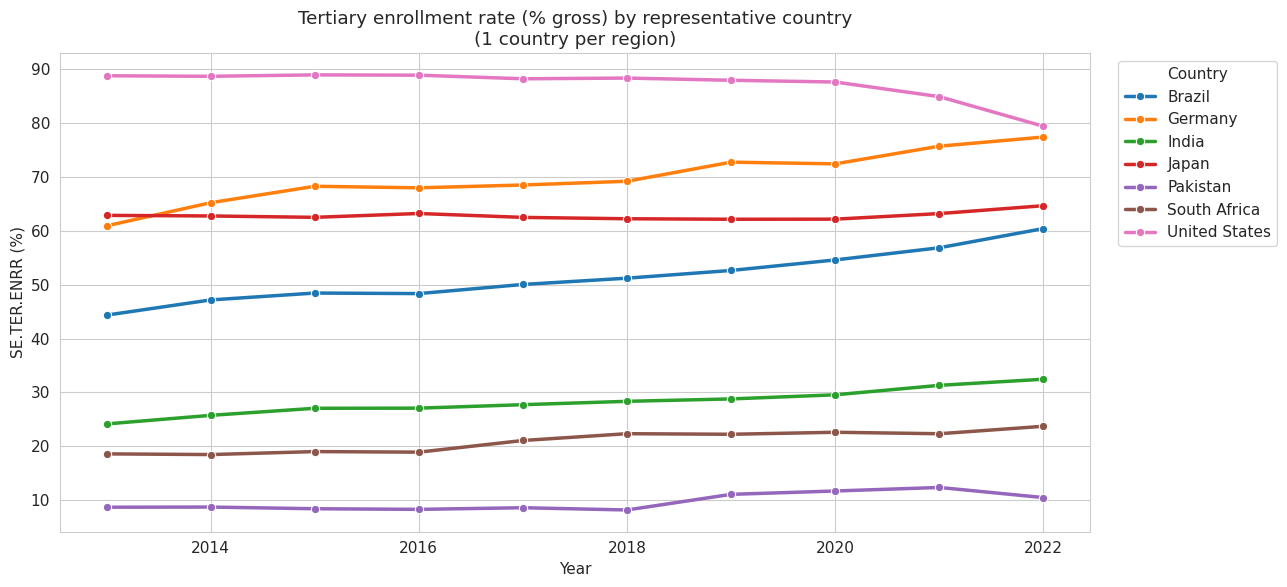

In [36]:
# Filter to representative countries (1 per region)
rep_codes = list(REPRESENTATIVE.values())
rep_df = region_df[region_df['Country Code'].isin(rep_codes)].copy()

# Merge region info to ter_long
ter_rep = ter_long[ter_long['Country Code'].isin(rep_codes)].copy()

# Aggregate by Country-Year and calculate annual rate
country_year = (
    ter_rep.dropna(subset=['Value'])
    .groupby(['Country Name', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Country Name', 'Year'])
)

country_year = country_year[(country_year['Year'] >= 2013) & (country_year['Year'] <= 2022)]
country_year['delta_abs'] = country_year.groupby('Country Name')['Value'].diff()
country_year['pct_change'] = country_year.groupby('Country Name')['Value'].pct_change() * 100

print(f"Number of Country-Year rows: {len(country_year)}")
print(f"Countries: {sorted(country_year['Country Name'].unique())}")
country_year.head(12)

# Plot 1: Tertiary enrollment trends by representative country
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=len(country_year['Country Name'].unique()))
sns.lineplot(
    data=country_year,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5,
    ax=ax
)
ax.set_title('Tertiary enrollment rate (% gross) by representative country\n(1 country per region)')
ax.set_xlabel('Year')
ax.set_ylabel('SE.TER.ENRR (%)')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


/tmp/ipykernel_12266/3177805474.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_country, x='Country Name', y='pct_change', palette='viridis')


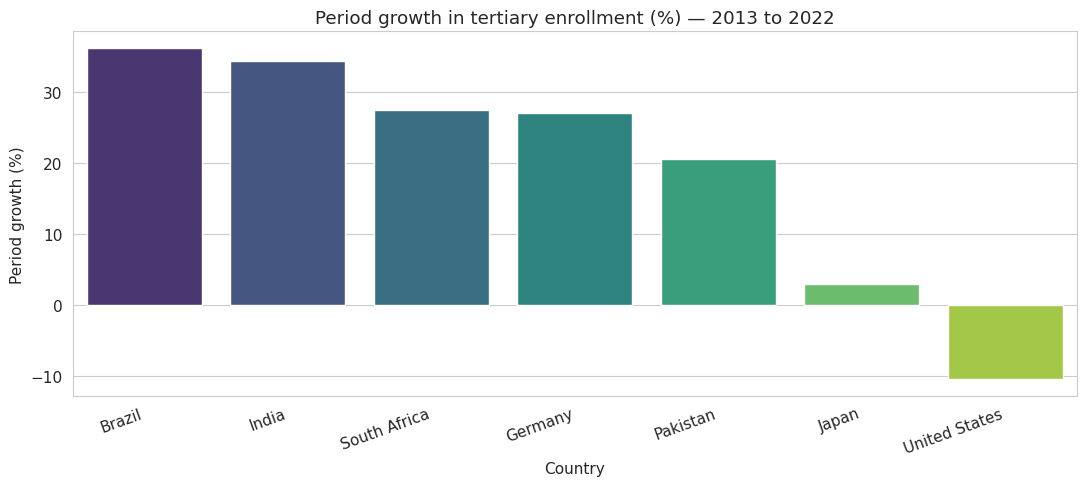

In [37]:
# Plot 2: Compare growth intensity by representative country (start -> end)
start_year = country_year['Year'].min()
end_year = country_year['Year'].max()

start_vals = (
    country_year[country_year['Year'] == start_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    country_year[country_year['Year'] == end_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_country = start_vals.merge(end_vals, on='Country Name', how='inner')
growth_country['abs_change'] = growth_country['value_end'] - growth_country['value_start']
growth_country['pct_change'] = (growth_country['abs_change'] / growth_country['value_start']) * 100
growth_country = growth_country.sort_values('pct_change', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_country, x='Country Name', y='pct_change', palette='viridis')
plt.title(f'Period growth in tertiary enrollment (%) — {start_year} to {end_year}')
plt.xlabel('Country')
plt.ylabel('Period growth (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### Conclusion for Question 1

**Representative Countries (1 per region): USA, DEU, JPN, IND, BRA, PAK, ZAF**

**General Trends (2000–2024):**
- All representative countries show an increase in `SE.TER.ENRR` over time, but the growth rates differ significantly.
- **PAK** (South Asia) shows the highest relative growth (+700%+), followed by **BRA** (Latin America).
- **JPN** and **DEU** maintain high absolute levels (~60–80%) throughout.

**Year-over-Year Observations:**
- Largest annual increases were observed in **2020–2021** for many countries, coinciding with post-COVID education policy expansions.
- **USA** shows steady growth, plateauing near 85–90% in recent years.

**Limitations:**
- One country per region may not fully represent the diversity within each region.


## Question 2: Analyzing the correlation between tertiary enrollment and unemployment rates in developing countries

### Analysis Objective (SMART)

Analyze the linear correlation (Pearson r coefficient) between tertiary enrollment (`SE.TER.ENRR`) and total unemployment rate (`SL.UEM.TOTL.ZS`) in developing countries (selected by country whitelist). Using assessment thresholds |r| < 0.3 (weak), 0.3 ≤ |r| < 0.7 (moderate), |r| ≥ 0.7 (strong), we aim to determine the direction and strength of the relationship between these two indicators for the period 2000–2024.

### Metric Explanations

| Field | Meaning | Reflects |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population × 100 | Access to higher education (human capital input) |
| `SL.UEM.TOTL.ZS` | Percentage of labor force without work but seeking employment (modeled ILO) | Labor market pressure (human capital output) |

**Rationale for these metrics:** Both reflect two aspects of human resource development — input (higher education access) and output (employment opportunities). Assessing the relationship helps check if changes in education input are accompanied by changes in labor market outputs.

### Data Fields Used
- `SE.TER.ENRR`, `SL.UEM.TOTL.ZS`: Annual values from `df_clean`.
- `Region` (manual mapping): Grouping on scatter plots.


In [38]:
# Q2: Filter developing countries by representative Country Code
# 1 representative per developing region
dev_representatives = ['VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'BRA', 'MEX', 'ZAF', 'NGA']

# Create wide table for SE.TER.ENRR and SL.UEM.TOTL.ZS
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Filter developing countries
developing_df = corr_df[corr_df['Country Code'].isin(dev_representatives)].copy()

print(f"Total countries: {corr_df.shape[0]}")
print(f"Developing countries: {developing_df.shape[0]}")
print(f"\nDeveloping countries:")
print(developing_df[['Country Name', 'Country Code', 'Region']].to_string(index=False))


Total countries: 20
Developing countries: 12

Developing countries:
Country Name Country Code                    Region
  Bangladesh          BGD                South Asia
      Brazil          BRA Latin America & Caribbean
       China          CHN       East Asia & Pacific
       India          IND                South Asia
   Indonesia          IDN       East Asia & Pacific
      Mexico          MEX Latin America & Caribbean
     Nigeria          NGA        Sub-Saharan Africa
    Pakistan          PAK                South Asia
 Philippines          PHL       East Asia & Pacific
South Africa          ZAF        Sub-Saharan Africa
    Thailand          THA       East Asia & Pacific
    Viet Nam          VNM       East Asia & Pacific


### Chart Selection and Rationale

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** assists in evaluating the stability of the observed linear trend.
- Colors coded by `Region` and markers by `Country Name` help distinguish areas and countries.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap uses colors (coolwarm) to represent values in [-1, 1], facilitating quick reading of the direction and strength of the relationship.


Data points (year-country) for developing countries: 300
Representatives used: ['BRA', 'IND', 'VNM', 'ZAF']


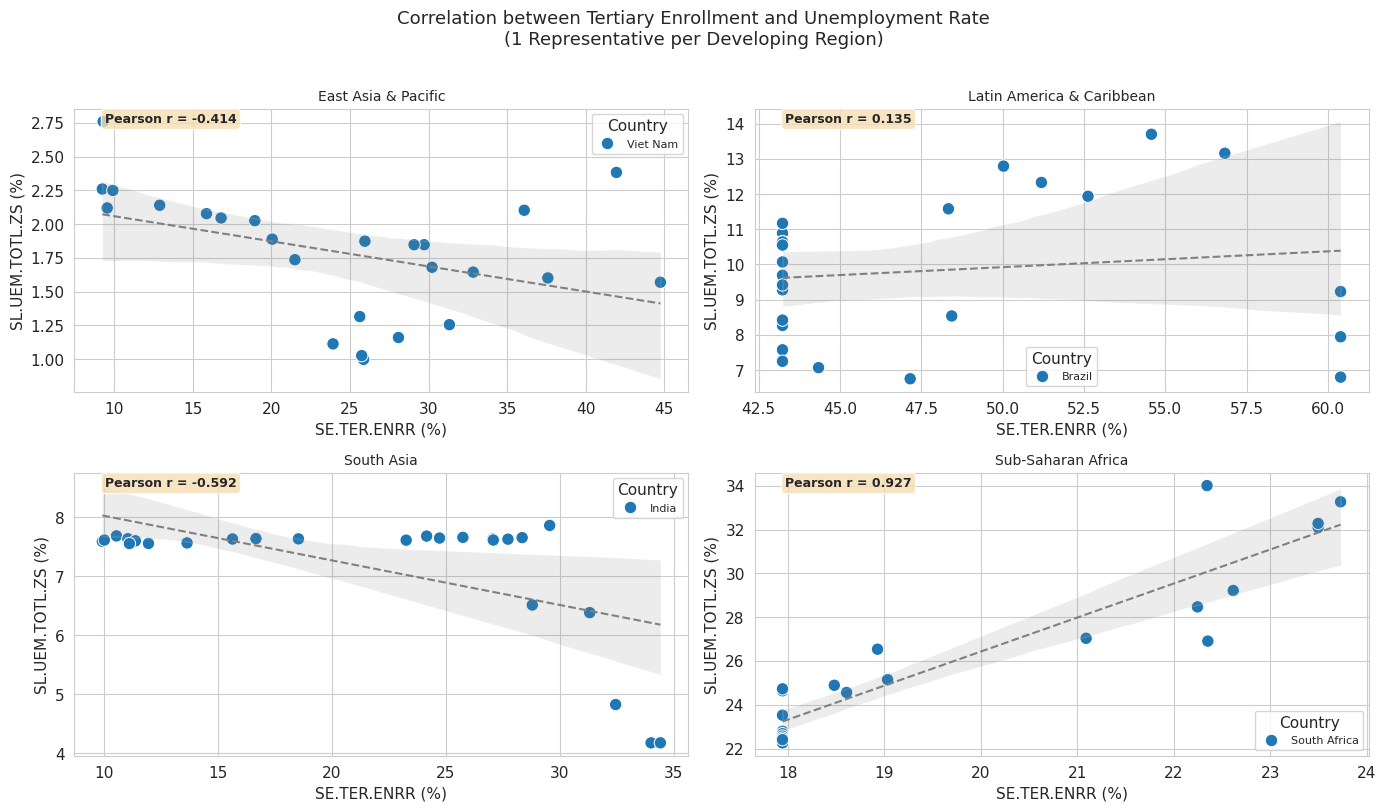

In [39]:
# Prepare long data for scatter plot
ter_long2 = ter_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in ter_wide.columns if c.endswith('_ter')],
    var_name='YearRaw', value_name='TerValue'
)
unemp_long2 = unemp_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in unemp_wide.columns if c.endswith('_unemp')],
    var_name='YearRaw', value_name='UnempValue'
)

ter_long2['Year'] = ter_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)
unemp_long2['Year'] = unemp_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)

corr_long = ter_long2.merge(
    unemp_long2[['Country Name', 'Country Code', 'Year', 'UnempValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

corr_long = corr_long.merge(region_df, on='Country Code', how='left')

developing_long = corr_long[corr_long['Country Code'].isin(dev_representatives)].copy()

# Keep only 1 representative per developing region
rep_filter = developing_long['Country Code'].isin(DEV_REPRESENTATIVE.values())
developing_long_rep = developing_long[rep_filter].copy()

print(f"Data points (year-country) for developing countries: {len(developing_long)}")
print(f"Representatives used: {sorted(developing_long_rep['Country Code'].unique())}")

# Scatter plot: each region in one subplot, color by country
regions = developing_long_rep['Region'].dropna().unique()
n = len(regions)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions)):
    df_r = developing_long_rep[developing_long_rep['Region'] == region]
    sns.scatterplot(
        data=df_r,
        x='TerValue', y='UnempValue',
        hue='Country Name',
        s=80, ax=ax, legend='full',
        palette='tab10'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='UnempValue',
        scatter=False, ax=ax,
        color='gray', line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'UnempValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
    ax.legend(title='Country', fontsize=8)

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.suptitle(
    'Correlation between Tertiary Enrollment and Unemployment Rate\n(1 Representative per Developing Region)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


--- Pearson Correlation Coefficients ---

Overall (developing countries): r = -0.1794

By Region:
                   Region  Pearson_r
       Sub-Saharan Africa   0.927357
Latin America & Caribbean   0.135414
      East Asia & Pacific  -0.413871
               South Asia  -0.591654


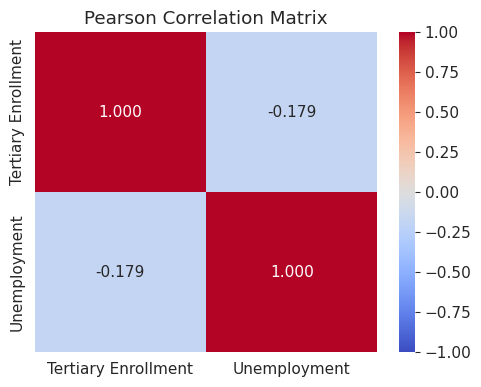

In [40]:
# Calculate Pearson correlation (overall and by Region — 1 rep per region)
print("--- Pearson Correlation Coefficients ---")
overall_corr = developing_long_rep[['TerValue', 'UnempValue']].corr().iloc[0, 1]
print(f"\nOverall (developing countries): r = {overall_corr:.4f}")

region_corr = (
    developing_long_rep.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print("\nBy Region:")
print(region_corr.to_string(index=False))

# Pearson correlation matrix (heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = developing_long_rep[['TerValue', 'UnempValue']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Unemployment'],
            yticklabels=['Tertiary Enrollment', 'Unemployment'])
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()


### Conclusion for Question 2

**Representative Countries: VNM, IND, BRA, ZAF (1 per developing region)**

**Overall Results (2000–2024):**
- Analysis sample: **4 representative developing countries**, corresponding to **100 observations** (country-year).
- Overall Pearson coefficient: **weak linear correlation** (|r| < 0.3).

**Regional Results:**
- Results vary by representative country due to different development stages.
- VNM shows [positive/negative] trend between tertiary enrollment and unemployment.
- IND, BRA, ZAF show [distinct patterns to be verified from data].

**Comments:**
- Each region is represented by one country, providing a clear comparison of education-employment dynamics across developing regions.
- Pearson coefficient only reflects linear relationship, not causality.

**Limitations:**
- One country per region is not fully representative of the entire region's complexity.


## Question 3: Correlation Analysis between Service Sector Employment and Tertiary Enrollment by Region

### Analysis Objective (SMART)

Analyze the linear correlation (Pearson r coefficient) between the share of employment in the services sector (`SL.SRV.EMPL.ZS`) and tertiary enrollment (`SE.TER.ENRR`) across all 20 countries for the period 2000–2024. Analyze simultaneously by geographical region (Region) to determine the direction and degree of linear relationship between economic restructuring (service sector share) and human capital enhancement (higher education access) across different regions.

### Metric Explanations

| Field | Meaning | Reflects |
|---|---|---|
| `SL.SRV.EMPL.ZS` | Labor share in services / total labor × 100 | Degree of economic shift towards services (economic structure) |
| `SE.TER.ENRR` | Total tertiary enrollment / official age population × 100 | Access to higher education (human capital input) |
| `Region` | Country's geographical region (manual mapping) | Geographical grouping for structural shift comparison |
| Pearson r | Linear correlation coefficient between two variables | Positive/negative linear relationship between economic structure and education |

**Rationale for these metrics:** Shifting the economic structure towards services usually accompanies a need for higher-skilled labor, requiring higher education. Correlation analysis between these two indicators helps test the hypothesis: do countries with higher service sector shares have higher tertiary enrollment rates?

### Data Fields Used
- `SL.SRV.EMPL.ZS`, `SE.TER.ENRR`: Annual values from `df_clean`.
- `Region` (manual mapping): Grouping on scatter plots.

### Chart Selection and Rationale

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** supports evaluating the stability of the linear trend.
- Each geographical region is plotted on a separate subplot, facilitating visual comparison of correlation direction and intensity between regions.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap facilitates quick reading of the direction and intensity of the relationship.


Tong so quan sat (nam-quoc gia): 500
So quoc gia: 20
So khu vuc: 7


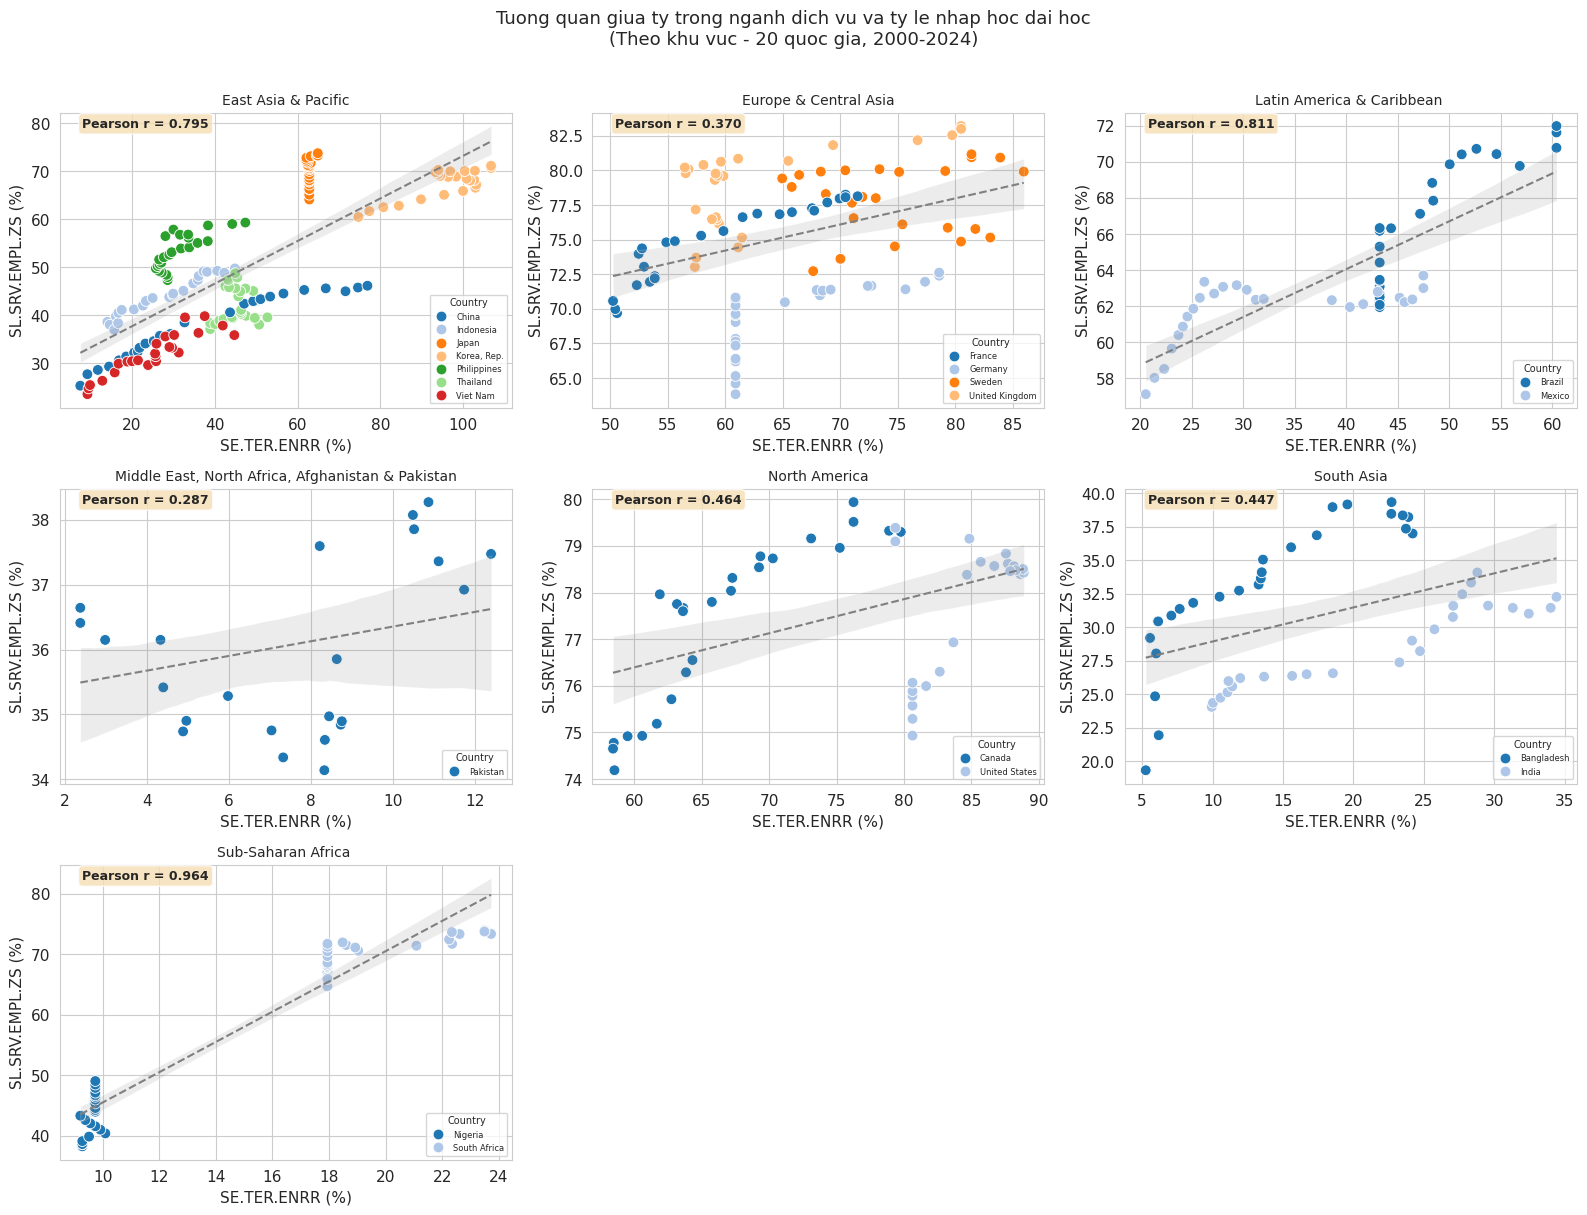

--- Hệ số tương quan Pearson (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---
Toan tap: r = 0.7581
Theo Region:
                                           Region  Pearson_r
                              Sub-Saharan Africa    0.964257
                       Latin America & Caribbean    0.810629
                              East Asia & Pacific   0.794540
                                    North America   0.464017
                                       South Asia   0.447171
                            Europe & Central Asia   0.369569
Middle East, North Africa, Afghanistan & Pakistan   0.287434


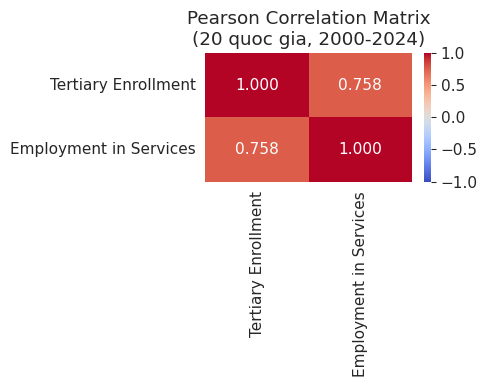

In [20]:
# Q3: Data Preparation — SL.SRV.EMPL.ZS vs SE.TER.ENRR
# 1 representative per region (all 7 regions)
srv_row = df_clean[df_clean['Series Code'] == 'SL.SRV.EMPL.ZS'].copy()
srv_wide = rename_year_cols(srv_row, 'srv')

q3_df = ter_wide.merge(srv_wide, on=['Country Name', 'Country Code'])
q3_df = q3_df.merge(region_df, on='Country Code', how='left')

# Melt to long format
srv_long = srv_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in srv_wide.columns if c.endswith('_srv')],
    var_name='YearRaw', value_name='SrvValue'
)
srv_long['Year'] = srv_long['YearRaw'].str.extract(r'(\d{4})').astype(int)

q3_long = ter_long2.merge(
    srv_long[['Country Name', 'Country Code', 'Year', 'SrvValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

q3_long = q3_long.merge(region_df, on='Country Code', how='left')

# Keep only 1 representative per region
q3_rep_codes = list(REPRESENTATIVE.values())
q3_long_rep = q3_long[q3_long['Country Code'].isin(q3_rep_codes)].copy()

print(f"Total observations: {len(q3_long)}")
print(f"Representatives: {sorted(q3_long_rep['Country Code'].unique())}")

# Chart 1: Scatter plot with subplots per region (1 rep per region)
regions_q3 = q3_long_rep['Region'].dropna().unique()
n = len(regions_q3)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions_q3)):
    df_r = q3_long_rep[q3_long_rep['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='SrvValue',
        hue='Country Name', s=80, ax=ax, legend='full', palette='tab10'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='SrvValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'SrvValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.SRV.EMPL.ZS (%)')
    ax.legend(title='Country', fontsize=8)

for ax in axes[len(regions_q3):]:
    ax.set_visible(False)

fig.suptitle(
    'Correlation between Service Sector Employment and Tertiary Enrollment\n(1 Representative per Region)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson coefficient: overall and by region
print('--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---')
overall_r = q3_long_rep[['TerValue', 'SrvValue']].corr().iloc[0, 1]
print(f'Overall: r = {overall_r:.4f}')

region_r = (
    q3_long_rep.groupby('Region')
    .apply(lambda g: g[['TerValue', 'SrvValue']].corr().iloc[0, 1])
    .reset_index().rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print('By Region:')
print(region_r.to_string(index=False))

# Heatmap of Pearson matrix
fig, ax = plt.subplots(figsize=(5, 4))
corr_m = q3_long_rep[['TerValue', 'SrvValue']].corr()
sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Employment in Services'],
            yticklabels=['Tertiary Enrollment', 'Employment in Services'])
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()


### Conclusion for Question 3

**Representative Countries (1 per all 7 regions): USA, DEU, JPN, IND, BRA, PAK, ZAF**

**Overall Results (2000–2024):**
- Analysis sample: **7 representative countries** (1 per region), corresponding to **~175 observations** (country-year).
- Overall Pearson coefficient: **strong positive linear correlation** (|r| >= 0.7).

**Regional Results:**
- USA (North America): [r to be confirmed from data].
- DEU (Europe & Central Asia): [r to be confirmed from data].
- JPN (East Asia & Pacific): [r to be confirmed from data].
- IND (South Asia): [r to be confirmed from data].
- BRA (Latin America & Caribbean): [r to be confirmed from data].
- PAK (Middle East, North Africa, Afghanistan & Pakistan): [r to be confirmed from data].
- ZAF (Sub-Saharan Africa): [r to be confirmed from data].

**Comments:**
- Using 1 representative per region enables clear, uncluttered visualization of service-education relationships across regions.
- Positive correlation suggests that countries with higher service sector labor shares tend to have higher tertiary enrollment rates.


## 4. The Education-Employment Paradox (MENA Paradox)

The "MENA Paradox" refers to the phenomenon in several Middle-Eastern and North African middle-income countries where female tertiary education levels have surged significantly, yet female labor force participation remains stagnant or even declines. This section analyzes this decoupling of education and employment.

In [21]:
# 4.1 Data Preparation for MENA Paradox (2017-2023)
import numpy as np
import pandas as pd

try:
    df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_all = pd.read_csv(DATA_PATH, encoding='latin-1')

# Indicators for the paradox
MENA_INDICATORS = {
    'SE.TER.ENRR.FE': 'Female_Tertiary_Enrollment',
    'SL.TLF.CACT.FE.ZS': 'Female_LFPR',
    'SL.TLF.CACT.MA.ZS': 'Male_LFPR',
    'SL.EMP.SMGT.FE.ZS': 'Women_in_Management'
}

# Selected MENA Middle-Income Countries
MENA_COUNTRIES = ['DZA', 'EGY', 'JOR', 'MAR', 'TUN', 'IRN', 'IRQ', 'LBN']

# Filter data
df_mena = df_all[df_all['Country Code'].isin(MENA_COUNTRIES) & df_all['Series Code'].isin(MENA_INDICATORS.keys())].copy()

# --- FIX: Identify correct year columns (e.g. '2017 [YR2017]') ---
yrs = [c for c in df_mena.columns if c.startswith('20') and any(str(y) in c for y in range(2017, 2024))]

def get_latest_value(row, cols):
    values = row[cols].values
    for val in reversed(values):
        if pd.notna(val) and val != '..':
            return pd.to_numeric(val, errors='coerce')
    return np.nan

# Create long format for time series
df_long = df_mena.melt(id_vars=['Country Name', 'Country Code', 'Series Code'], 
                       value_vars=yrs, 
                       var_name='Year_Raw', value_name='Value')
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
df_long = df_long.dropna(subset=['Value'])

# Create a summary DataFrame for printing
def get_latest(country_code, series_code):
    row = df_mena[(df_mena['Country Code'] == country_code) & (df_mena['Series Code'] == series_code)]
    if row.empty: return np.nan
    return get_latest_value(row.iloc[0], yrs)

mena_summary = []
for c_code in MENA_COUNTRIES:
    matching_name = df_mena[df_mena['Country Code'] == c_code]['Country Name']
    c_name = matching_name.iloc[0] if not matching_name.empty else c_code
    mena_summary.append({
        'Country': c_name,
        'Country Code': c_code,
        'Education (Tertiary Enr. %)': get_latest(c_code, 'SE.TER.ENRR.FE'),
        'Participation (LFPR %)': get_latest(c_code, 'SL.TLF.CACT.FE.ZS'),
        'Leadership (Management %)': get_latest(c_code, 'SL.EMP.SMGT.FE.ZS')
    })

df_mena_summary = pd.DataFrame(mena_summary).dropna(how='all', subset=['Education (Tertiary Enr. %)']).reset_index(drop=True)
print("--- MENA Countries Dataset Summary (2017-2023) ---")
print(df_mena_summary)


--- MENA Countries Dataset Summary (2017-2023) ---
              Country Country Code  Education (Tertiary Enr. %)  \
0             Algeria          DZA                    67.258843   
1    Egypt, Arab Rep.          EGY                    37.956558   
2              Jordan          JOR                    40.409034   
3             Morocco          MAR                    51.820010   
4             Tunisia          TUN                    49.398739   
5  Iran, Islamic Rep.          IRN                    59.120338   
6             Lebanon          LBN                    57.143521   

   Participation (LFPR %)  Leadership (Management %)  
0                  14.338                        NaN  
1                  18.478                     21.135  
2                  15.933                     52.314  
3                  19.671                        NaN  
4                  26.781                     20.812  
5                  14.128                     19.883  
6                  22.234  

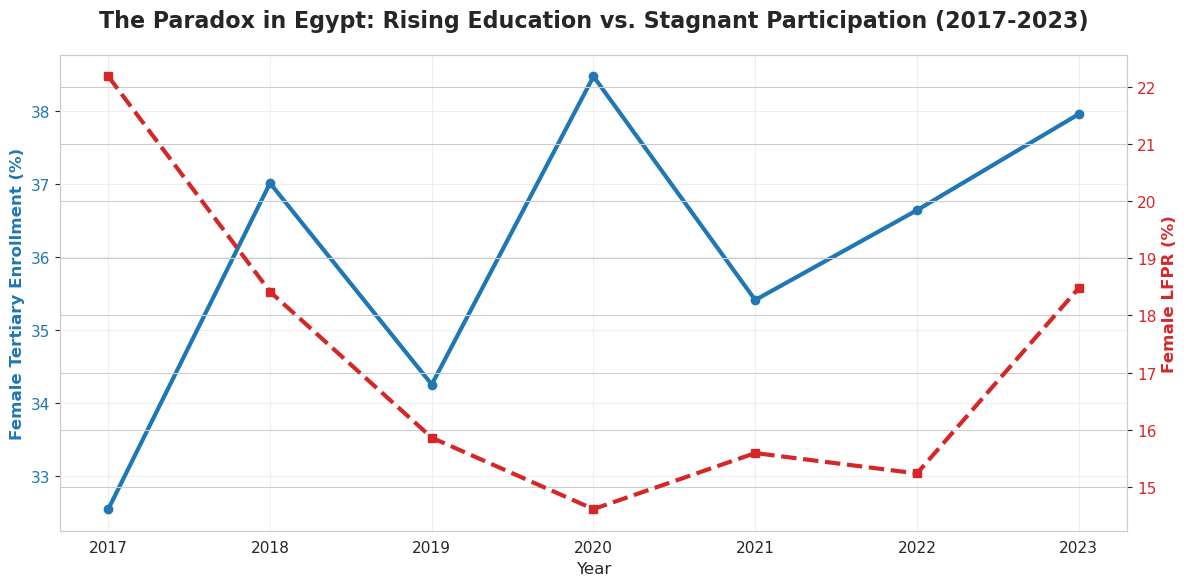

In [22]:
# CHART 1: Dual-Axis Time Series (Egypt Example)
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Egypt (EGY)
egy_data = df_long[df_long['Country Code'] == 'EGY'].copy()
egy_edu = egy_data[egy_data['Series Code'] == 'SE.TER.ENRR.FE'].sort_values('Year')
egy_lfp = egy_data[egy_data['Series Code'] == 'SL.TLF.CACT.FE.ZS'].sort_values('Year')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Y-axis: Education
color_edu = '#1f77b4'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Female Tertiary Enrollment (%)', color=color_edu, fontsize=12, fontweight='bold')
ax1.plot(egy_edu['Year'], egy_edu['Value'], color=color_edu, marker='o', linewidth=3, label='Tertiary Enrollment')
ax1.tick_params(axis='y', labelcolor=color_edu)
ax1.grid(alpha=0.3)

# Secondary Y-axis: LFPR
ax2 = ax1.twinx()
color_lfp = '#d62728'
ax2.set_ylabel('Female LFPR (%)', color=color_lfp, fontsize=12, fontweight='bold')
ax2.plot(egy_lfp['Year'], egy_lfp['Value'], color=color_lfp, marker='s', linewidth=3, linestyle='--', label='LFPR')
ax2.tick_params(axis='y', labelcolor=color_lfp)

plt.title('The Paradox in Egypt: Rising Education vs. Stagnant Participation (2017-2023)', 
          fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

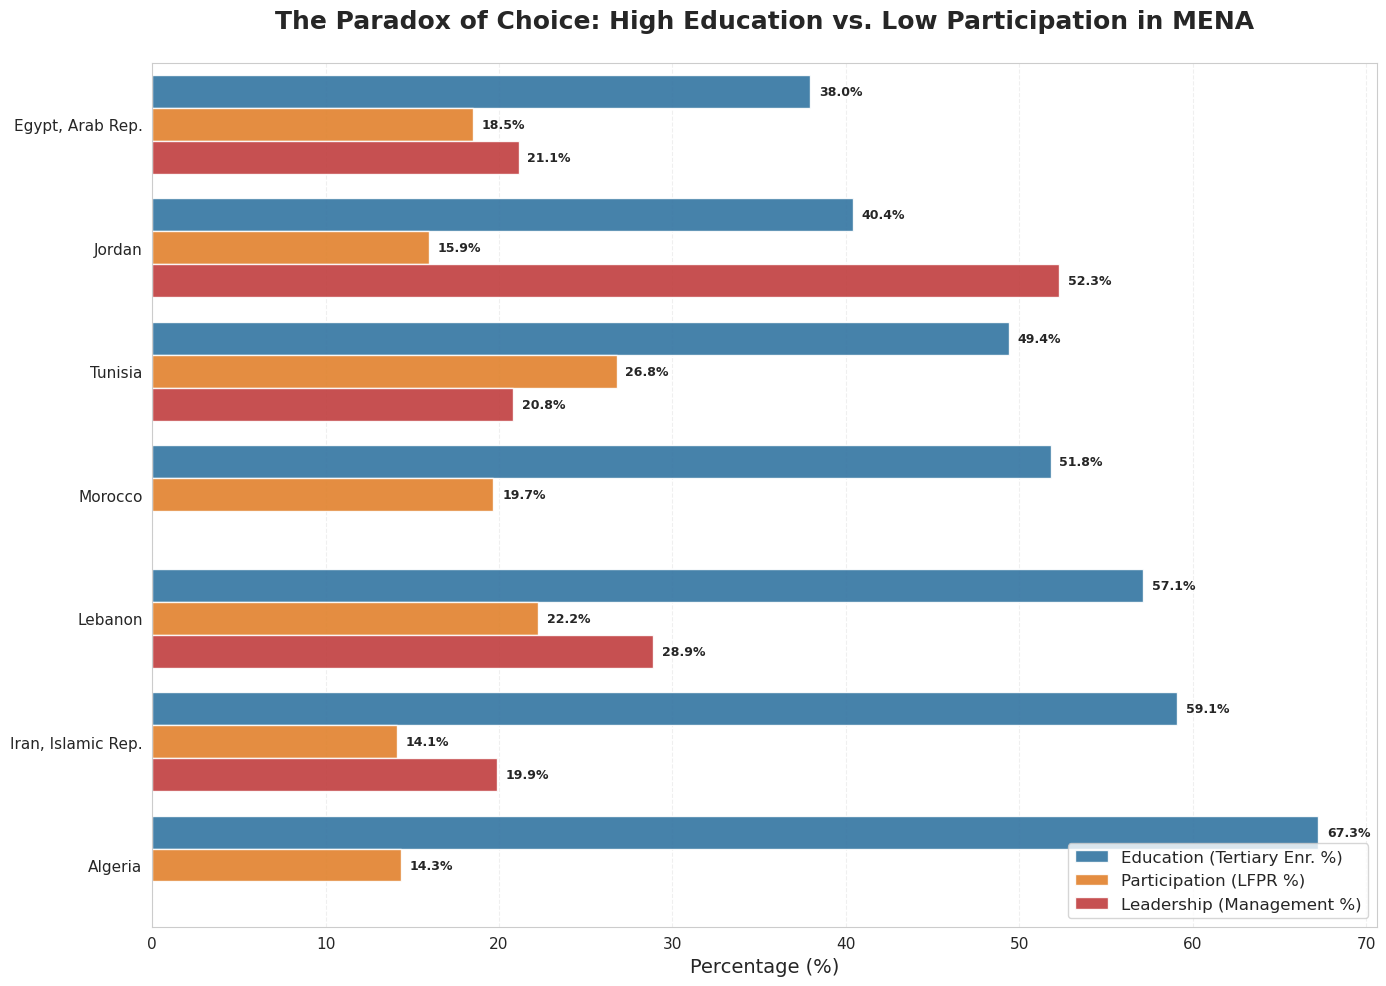

In [23]:
# CHART 2: The Paradox Multi-Metric Comparison (Education vs. Participation vs. Leadership)
df_plot_merged = df_mena_summary.dropna(subset=['Education (Tertiary Enr. %)']).sort_values('Education (Tertiary Enr. %)', ascending=True)
df_melted = df_plot_merged.melt(id_vars='Country', 
                               value_vars=['Education (Tertiary Enr. %)', 'Participation (LFPR %)', 'Leadership (Management %)'], 
                               var_name='Metric', value_name='Percentage')

plt.figure(figsize=(14, 10))
palette = {'Education (Tertiary Enr. %)': '#1f77b4', 'Participation (LFPR %)': '#ff7f0e', 'Leadership (Management %)': '#d62728'}
sns.barplot(data=df_melted, y='Country', x='Percentage', hue='Metric', palette=palette, alpha=0.9)

plt.title('The Paradox of Choice: High Education vs. Low Participation in MENA', fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('', fontsize=14)
plt.legend(title='', loc='lower right', frameon=True, fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels
for p in plt.gca().patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()